In [1]:
import scanpy as sc
import anndata as ad
# import rapids_singlecell as rsc
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
from collections import defaultdict

import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/mid_hind_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata.obs_names_make_unique()
adata

AnnData object with n_obs × n_vars = 6335480 × 33343
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    uns: 'dmt_leiden_colors', 'dmt_leiden_merge_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [3]:
adata = adata[:, ~adata.var_names.str.startswith('MT')]
adata = adata[:,[False if '.' in i else True for i in adata.var.index.tolist()]]
adata

View of AnnData object with n_obs × n_vars = 6335480 × 23137
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    uns: 'dmt_leiden_colors', 'dmt_leiden_merge_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [4]:
adatas = []
for i in set(adata.obs['slice_code']):
    temp = adata[adata.obs['slice_code'] == i].copy()
    sc.pp.normalize_total(temp)
    sc.pp.log1p(temp)
    sc.pp.scale(temp, zero_center=False, max_value=10)
    adatas.append(temp)
adata = ad.concat(adatas)

In [6]:
csv = pd.read_csv('/data/work/05.cluster/FuseMap/0313/mid_hind_spatial/dmt_leiden_merge_rapids_deg.csv')
dic = {}
for i in set(csv['dmt_leiden_merge']):
    dic[i] = csv[csv['dmt_leiden_merge'] == i].names.tolist()[:5]
sorted_dict = dict(sorted(dic.items(), key=lambda item: int(item[0].replace('mh_', ''))))

In [10]:
sorted_dict = {'mh_0': ['NKX2-4', 'NKX2-8', 'NKX6-2','CRH'],
 'mh_1': ['HBG2', 'HBA2', 'HBG1', 'HBA1', 'OTX2'],
 'mh_2': ['PMCH', 'ALDH1A1', 'PITX2', 'NTS', 'TH'],
 'mh_3': ['CABP2'],
 'mh_4': ['TTR', 'PCDH9'],
 'mh_5': ['TFAP2B', 'CCK'],
 'mh_6': ['TCF7L2', 'PTH2', 'GPR151', 'KITLG'],
 'mh_7': ['CRABP1', 'NFIB', 'LMO4', 'MAP1B'],
 'mh_8': ['HOXB5', 'HOXA5', 'HOXB8', 'HOXB6', 'MAFA'],
 'mh_9': ['CST3', 'C1orf61'],
 'mh_10': ['NPY', 'LHX9', 'TFAP2D'],
 'mh_11': ['LAMP5', 'PEG10', 'MEIS2'],
 'mh_12': ['SPP1', 'FTL', 'MAGEA1', 'LINC00293', 'APOE'],
 'mh_14': ['OTP', 'LHX5-AS1', 'GATA3'],
 'mh_15': ['NEFL', 'NEFM', 'CARTPT', 'PRPH'],
 'mh_16': ['PAX5', 'TPH2', 'SLC6A4', 'FEV', 'DBH'],
 'mh_17': ['IGFBP7', 'CLDN5', 'FN1', 'ITM2A'],
 'mh_18': ['SST', 'PHOX2B', 'CBLN1', 'LINC00682']}

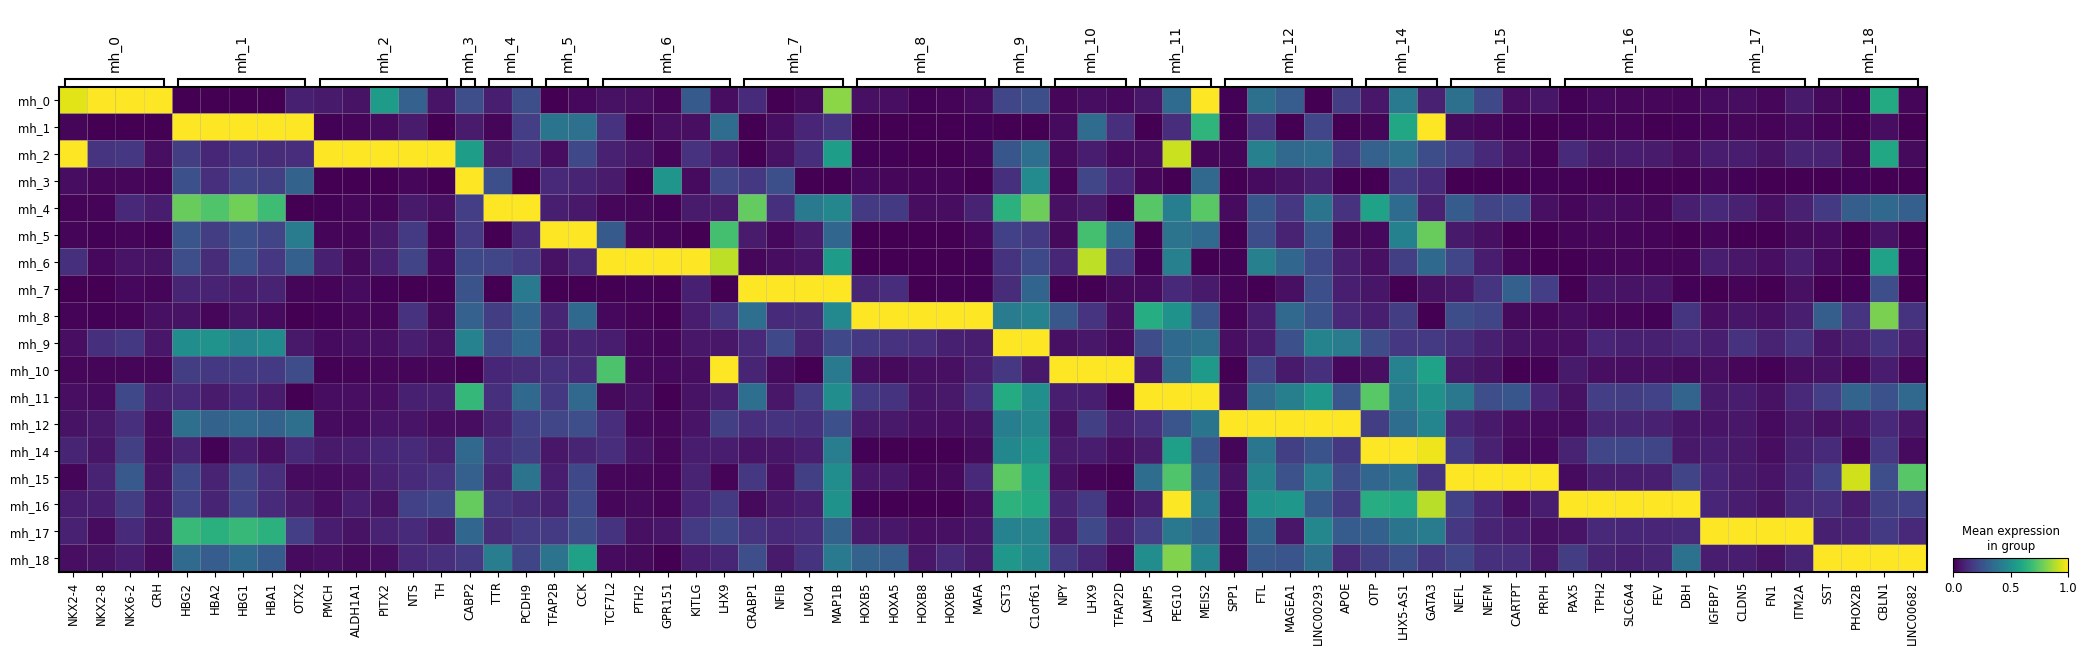

In [11]:
sc.pl.matrixplot(adata, 
                 sorted_dict, 
                 'dmt_leiden_merge', 
                 standard_scale = 'var',
                 # dendrogram = True,
                 # show = False
                )

In [12]:
adata

AnnData object with n_obs × n_vars = 6335480 × 23137
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'Tangram_1119_celltype', 'Tangram_1119_celltype_main_frac', 'slice_code', 'sub_region', 'dmt_leiden', 'dmt_leiden_merge'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'

In [14]:
dmt_leiden_anno = list(set(adata.obs['dmt_leiden_merge']))
number_of_colors = len(dmt_leiden_anno)
colors = np.random.rand(number_of_colors, 3)
custom_cmap = ListedColormap(colors)
hex_colors = [rgb2hex(color) for color in custom_cmap.colors]
colormap = {dmt_leiden_anno[i]:hex_colors[i] for i in range(number_of_colors) }

In [15]:
colormap

{'mh_12': '#244320',
 'mh_8': '#a374bd',
 'mh_16': '#a4f2d4',
 'mh_2': '#db8c2c',
 'mh_14': '#d359aa',
 'mh_9': '#5f31de',
 'mh_1': '#ae83b8',
 'mh_4': '#26f77e',
 'mh_18': '#f5ee2f',
 'mh_11': '#dbb1c9',
 'mh_17': '#0cd53a',
 'mh_10': '#1607d3',
 'mh_3': '#b58c76',
 'mh_15': '#2c8fb2',
 'mh_6': '#727d30',
 'mh_7': '#3bbc7d',
 'mh_5': '#68754f',
 'mh_0': '#c9cd19'}